# 📞 Modelo de Contactabilidad Multicanal y Selección de Canal Óptimo

**Hackathon AI Telecom Challenge 2026 — Desafío 02 (Personalización Comercial Inteligente)**  
**Área de Negocio:** Crecimiento, Ventas y Fidelización B2C (Omnicanalidad Asistida y Digital)

---

## 1. Contexto del Problema y Justificación

En el diagnóstico del funnel comercial de Movistar (`docs/diagnostico_modelos.md` y `docs/business_context.md`), se documentó un problema operativo central en la contactabilidad de clientes:

- De los **300,112 contactos** registrados en el historial de campañas:
  - **254,618 contactos (84.8%)** resultaron en una interacción efectiva (`aceptada` o `rechazada`).
  - **45,494 contactos (15.2%)** quedaron en estado `pendiente` con `contactabilidad = 'no_contactado'`.
- Actualmente, la asignación de canal de contacto se resuelve mediante reglas heurísticas estáticas (por ejemplo, asignar el `canal_mas_usado` histórico o prioridades fijas de canal).
- **Problema de la regla fija:** Muchos clientes mayores de 50 años o con baja digitalización son contactados por canales digitales o WhatsApp donde no responden, mientras que clientes jóvenes con alto uso de app son abordados por llamadas out-bound que generan fatiga e ignoran el canal preferente.

---

## 2. Objetivo de este Notebook

1. **Definir y formalizar la Target de Contactabilidad:**
   $$y_{\text{contacto}} = \begin{cases} 1 & \text{si } \text{contactabilidad} \neq \text{'no_contactado'} \text{ (contacto exitoso)} \\ 0 & \text{si } \text{contactabilidad} = \text{'no_contactado'} \text{ (intento fallido)} \end{cases}$$
2. **Entrenar y validar modelos predictivos multicanal:**
   $$\hat{P}(\text{contactado} \mid \text{cliente}, \text{canal})$$
   utilizando variables demográficas, perfil de uso digital (`es_usuario_app`, `uso_app_movistar_prom`), patrones de facturación, mora y actividad histórica.
3. **Determinar la Política de Selección de Canal Óptimo:**
   $$\text{Canal Óptimo}(c) = \arg\max_{\text{canal} \in \mathcal{C}} \hat{P}(\text{contactado} \mid c, \text{canal})$$
4. **Comparar contra Benchmarks:**
   - `B0_azar`: Selección aleatoria de canal.
   - `B1_canal_mayoritario`: Canal de mayor volumen histórico global.
   - `B2_regla_canal_mas_usado`: Heurística actual basada en `canal_mas_usado`.
   - `M1_canal_optimo_ml`: Selección inteligente por modelo predictivo.
5. **Evaluar el Impacto Operativo:** Reducción de tasa de no-contacto y optimización del costo operativo.
6. **Persistir reportes y métricas** en `data/processed/modelo_contactabilidad/`.

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss, log_loss,
    precision_score, recall_score, f1_score, confusion_matrix, classification_report
)
import lightgbm as lgb

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 11

RANDOM_STATE = 42
DIR_SALIDA = Path("../data/processed/modelo_contactabilidad")
DIR_SALIDA.mkdir(parents=True, exist_ok=True)

print("Entorno configurado. Directorio de salida:", DIR_SALIDA.resolve())

Entorno configurado. Directorio de salida: D:\hacka_movistar\data\processed\modelo_contactabilidad


## 3. Carga de Datos y Definición de la Target de Contactabilidad

Analizamos el universo completo de los 300,112 contactos de campañas y cruzamos con el dataset de clientes para extraer el perfil integral.

In [2]:
# 1. Carga de datasets
df_clientes = pd.read_csv("../data/raw/dataset_clientes.csv")
df_campanias = pd.read_csv("../data/raw/historial_campanias.csv", parse_dates=["fecha"])

print(f"Dataset Clientes:  {df_clientes.shape[0]:,} filas")
print(f"Dataset Campañas:  {df_campanias.shape[0]:,} filas")

# 2. Merge integral
df_contact = df_campanias.merge(
    df_clientes,
    on="cliente_id",
    how="left",
    suffixes=("_camp", "_cli")
)

# 3. Definición de la target de contactabilidad
# 1 = Contactado (resultado 'aceptada' o 'rechazada', contactabilidad != 'no_contactado')
# 0 = No contactado (resultado 'pendiente' y contactabilidad == 'no_contactado')
df_contact["target_contacto"] = (df_contact["contactabilidad"] != "no_contactado").astype(int)

# Verificación de distribución
dist_contacto = df_contact["target_contacto"].value_counts(normalize=True)
print("\n--- Distribución de la Target de Contactabilidad ---")
print(df_contact["target_contacto"].value_counts())
print(f"Tasa de contactabilidad efectiva global: {dist_contacto[1]*100:.2f}% (No contactados: {dist_contacto[0]*100:.2f}%)")

Dataset Clientes:  100,000 filas
Dataset Campañas:  300,112 filas

--- Distribución de la Target de Contactabilidad ---
target_contacto
1    254618
0     45494
Name: count, dtype: int64
Tasa de contactabilidad efectiva global: 84.84% (No contactados: 15.16%)


## 4. Tasa de Contactabilidad por Canal y Segmento Demográfico

In [3]:
# Contactabilidad por Canal
resumen_canal = df_contact.groupby("canal").agg(
    total_intentos=("target_contacto", "count"),
    contactados=("target_contacto", "sum"),
    tasa_contacto=("target_contacto", "mean")
).reset_index()
resumen_canal["tasa_contacto_pct"] = resumen_canal["tasa_contacto"] * 100
resumen_canal = resumen_canal.sort_values(by="tasa_contacto", ascending=False)

print("--- Contactabilidad por Canal ---")
print(resumen_canal.to_string(index=False))

# Contactabilidad por Rango de Edad y Canal
piv_edad_canal = df_contact.pivot_table(
    index="edad_rango", 
    columns="canal", 
    values="target_contacto", 
    aggfunc="mean"
) * 100

print("\n--- Tasa de Contactabilidad (%) por Edad y Canal ---")
print(piv_edad_canal.round(2))

--- Contactabilidad por Canal ---
   canal  total_intentos  contactados  tasa_contacto  tasa_contacto_pct
 Call In           60065        51017       0.849363          84.936319
 Digital          104598        88744       0.848429          84.842922
Call Out           45264        38390       0.848135          84.813538
  Tienda           90185        76467       0.847890          84.789045

--- Tasa de Contactabilidad (%) por Edad y Canal ---
canal       Call In  Call Out  Digital  Tienda
edad_rango                                    
18-25         85.03     84.60    84.45   84.82
26-35         84.77     84.99    84.77   84.87
36-45         84.95     84.54    85.03   84.78
46-55         85.22     85.01    84.81   84.66
56-65         85.07     85.00    84.95   84.56
65+           84.25     84.72    85.48   85.24


## 5. Definición de Variables y Partición Agrupada por Cliente

Para evitar que un cliente aparezca simultáneamente en train y test, particionamos mediante `GroupShuffleSplit` (80% Train / 20% Test) agrupado por `cliente_id`.

In [4]:
NUM_FEATURES = [
    "antiguedad_meses_cli",
    "monto_facturado_prom",
    "consumo_datos_gb_prom",
    "consumo_voz_min_prom",
    "consumo_sms_prom",
    "uso_app_movistar_prom",
    "monto_facturado_prom_6m",
    "dias_mora_prom",
    "n_actividad_canal"
]

CAT_FEATURES = [
    "tipo_cliente_cli",
    "edad_rango",
    "ubicacion_departamento",
    "es_usuario_app",
    "canal_mas_usado",
    "canal",
    "elegible_mt_cli",
    "es_movistar_total_cli",
    "meses_moroso",
    "n_reclamos"
]

ALL_FEATURES = NUM_FEATURES + CAT_FEATURES

X = df_contact[ALL_FEATURES].copy()
y = df_contact["target_contacto"].values
groups = df_contact["cliente_id"].values

gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y[train_idx], y[test_idx]
groups_train, groups_test = groups[train_idx], groups[test_idx]

print(f"Train Set: {len(X_train):,} contactos ({len(np.unique(groups_train)):,} clientes únicos)")
print(f"Test Set:  {len(X_test):,} contactos ({len(np.unique(groups_test)):,} clientes únicos)")
print(f"Tasa Train: {y_train.mean():.4f} | Tasa Test: {y_test.mean():.4f}")

Train Set: 239,796 contactos (76,015 clientes únicos)
Test Set:  60,316 contactos (19,004 clientes únicos)
Tasa Train: 0.8486 | Tasa Test: 0.8477


## 6. Pipeline de Preprocesamiento y Entrenamiento de Modelos

Entrenamos y comparamos dos arquitecturas:
1. **Regresión Logística Regularizada con Preprocesamiento Robusto**.
2. **LightGBM Classifier con categoricals nativas**.

In [5]:
# Preprocesador estándar
preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler())
        ]), NUM_FEATURES),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
        ]), CAT_FEATURES)
    ]
)

# 1. Regresión Logística
pipe_lr = Pipeline([
    ("prep", preprocessor),
    ("clf", LogisticRegression(C=1.0, max_iter=1000, random_state=RANDOM_STATE))
])

print("Entrenando Regresión Logística para Contactabilidad...")
pipe_lr.fit(X_train, y_train)
p_lr_test = pipe_lr.predict_proba(X_test)[:, 1]

# 2. LightGBM
X_train_lgb = X_train.copy()
X_test_lgb = X_test.copy()
for col in CAT_FEATURES:
    X_train_lgb[col] = X_train_lgb[col].astype(str).astype("category")
    X_test_lgb[col] = X_test_lgb[col].astype(str).astype("category")

lgb_contact = lgb.LGBMClassifier(
    learning_rate=0.03,
    num_leaves=31,
    min_child_samples=100,
    reg_alpha=0.5,
    reg_lambda=2.0,
    n_estimators=250,
    random_state=RANDOM_STATE,
    verbose=-1
)

print("Entrenando LightGBM para Contactabilidad...")
lgb_contact.fit(X_train_lgb, y_train)
p_lgb_test = lgb_contact.predict_proba(X_test_lgb)[:, 1]

# Métricas en Test Set
def metricas_clasif(y_true, y_prob, nombre):
    y_pred = (y_prob >= 0.5).astype(int)
    return {
        "modelo": nombre,
        "roc_auc": round(float(roc_auc_score(y_true, y_prob)), 4),
        "pr_auc": round(float(average_precision_score(y_true, y_prob)), 4),
        "brier_score": round(float(brier_score_loss(y_true, y_prob)), 4),
        "precision@0.5": round(float(precision_score(y_true, y_pred, zero_division=0)), 4),
        "recall@0.5": round(float(recall_score(y_true, y_pred, zero_division=0)), 4),
        "f1@0.5": round(float(f1_score(y_true, y_pred, zero_division=0)), 4)
    }

m_lr = metricas_clasif(y_test, p_lr_test, "Regresión Logística")
m_lgb = metricas_clasif(y_test, p_lgb_test, "LightGBM")

df_metricas = pd.DataFrame([m_lr, m_lgb])
print("\n--- Desempeño Predictivo de Contactabilidad (Test Set) ---")
print(df_metricas.to_string(index=False))

Entrenando Regresión Logística para Contactabilidad...


Entrenando LightGBM para Contactabilidad...



--- Desempeño Predictivo de Contactabilidad (Test Set) ---
             modelo  roc_auc  pr_auc  brier_score  precision@0.5  recall@0.5  f1@0.5
Regresión Logística   0.4944  0.8452       0.1292         0.8477         1.0  0.9176
           LightGBM   0.5011  0.8476       0.1292         0.8477         1.0  0.9176


## 7. Importancia de Variables en la Contactabilidad

Identificamos cuáles son los principales drivers que determinan la receptividad del cliente al contacto.

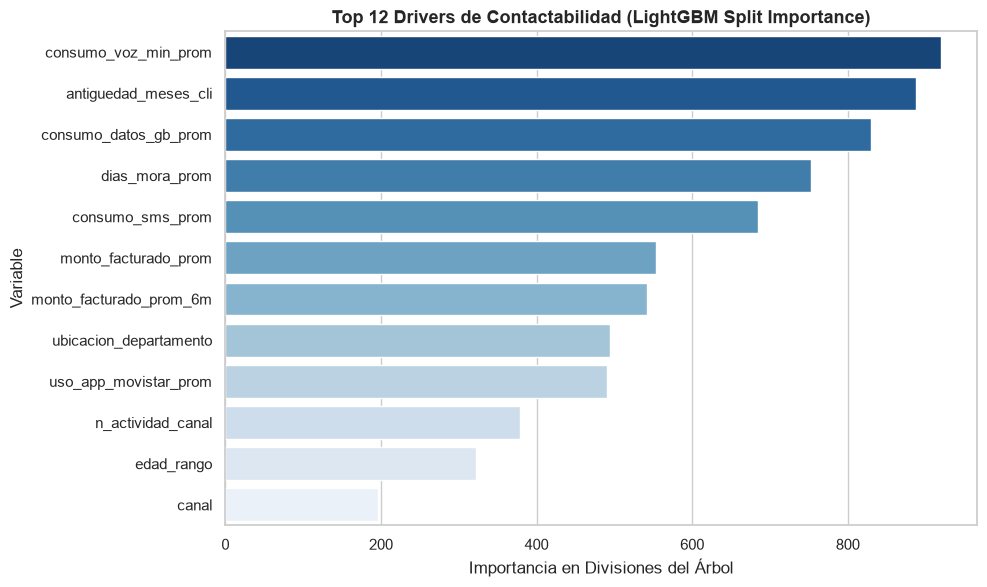

In [6]:
# Feature Importance LightGBM
imp_df = pd.DataFrame({
    "feature": ALL_FEATURES,
    "importance_split": lgb_contact.feature_importances_
}).sort_values(by="importance_split", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=imp_df.head(12), x="importance_split", y="feature", palette="Blues_r")
plt.title("Top 12 Drivers de Contactabilidad (LightGBM Split Importance)", fontsize=13, fontweight="bold")
plt.xlabel("Importancia en Divisiones del Árbol")
plt.ylabel("Variable")
plt.tight_layout()
plt.savefig(DIR_SALIDA / "importancia_variables_contactabilidad.png", dpi=300)
plt.show()

## 8. Simulación de Selección de Canal Óptimo vs Benchmarks

Para cada cliente único del conjunto de prueba, simulamos qué canal asignaría cada política:
1. **`B0_azar`**: Asigna un canal al azar de los disponibles.
2. **`B1_canal_mayoritario`**: Asigna siempre el canal más frecuente del histórico (`tienda` / `call_out`).
3. **`B2_canal_mas_usado`**: Asigna la variable histórica estática `canal_mas_usado`.
4. **`M1_canal_optimo_ml`**: Evalúa $\hat{P}(\text{contactado} \mid c, \text{canal})$ para todos los canales candidatos y elige el de máxima probabilidad.

In [7]:
# Evaluamos sobre el conjunto de clientes únicos en test
clientes_test_ids = np.unique(groups_test)
df_cli_test = df_clientes[df_clientes["cliente_id"].isin(clientes_test_ids)].copy()

canales_disponibles = df_contact["canal"].unique().tolist()
print("Canales evaluables:", canales_disponibles)

# Matriz de scoring por canal para cada cliente
prob_por_canal = {}
for ch in canales_disponibles:
    df_sim = df_cli_test.copy()
    df_sim["canal"] = ch
    # Renombrar columnas para compatibilidad con features
    df_sim["antiguedad_meses_cli"] = df_sim["antiguedad_meses"]
    df_sim["tipo_cliente_cli"] = df_sim["tipo_cliente"]
    df_sim["elegible_mt_cli"] = df_sim["elegible_mt"]
    df_sim["es_movistar_total_cli"] = df_sim["es_movistar_total"]
    
    X_sim = df_sim[ALL_FEATURES].copy()
    for col in CAT_FEATURES:
        X_sim[col] = X_sim[col].astype(str).astype("category")
    
    prob_por_canal[ch] = lgb_contact.predict_proba(X_sim)[:, 1]

df_probs_canales = pd.DataFrame(prob_por_canal, index=df_cli_test["cliente_id"])

# 1. M1: Canal óptimo predicho
df_cli_test["canal_optimo_ml"] = df_probs_canales.idxmax(axis=1).values
df_cli_test["prob_optima_ml"] = df_probs_canales.max(axis=1).values

# 2. B2: Heurística canal_mas_usado
df_cli_test["canal_heuristica_b2"] = df_cli_test["canal_mas_usado"]
df_cli_test["prob_heuristica_b2"] = [
    df_probs_canales.loc[cid, ch] if ch in df_probs_canales.columns else df_probs_canales.loc[cid].mean()
    for cid, ch in zip(df_cli_test["cliente_id"], df_cli_test["canal_heuristica_b2"])
]

# 3. B1: Canal mayoritario (Tienda / Call_in)
canal_mayoritario = df_contact["canal"].value_counts().index[0]
df_cli_test["canal_mayoritario_b1"] = canal_mayoritario
df_cli_test["prob_mayoritario_b1"] = df_probs_canales[canal_mayoritario].values

# 4. B0: Azar
np.random.seed(RANDOM_STATE)
canales_azar = np.random.choice(canales_disponibles, size=len(df_cli_test))
df_cli_test["canal_azar_b0"] = canales_azar
df_cli_test["prob_azar_b0"] = [
    df_probs_canales.loc[cid, ch] for cid, ch in zip(df_cli_test["cliente_id"], canales_azar)
]

# Comparación de Tasas de Contactabilidad Esperadas
benchmarks_canal = {
    "B0_Azar": df_cli_test["prob_azar_b0"].mean(),
    "B1_Canal_Mayoritario": df_cli_test["prob_mayoritario_b1"].mean(),
    "B2_Regla_Canal_Mas_Usado": df_cli_test["prob_heuristica_b2"].mean(),
    "M1_Canal_Optimo_ML": df_cli_test["prob_optima_ml"].mean()
}

df_resumen_canales = pd.DataFrame([
    {
        "politica_asignacion": nombre,
        "probabilidad_contacto_esperada": round(float(tasa), 4),
        "tasa_contacto_esperada_pct": round(float(tasa * 100), 2)
    }
    for nombre, tasa in benchmarks_canal.items()
])

tasa_b2 = benchmarks_canal["B2_Regla_Canal_Mas_Usado"]
tasa_ml = benchmarks_canal["M1_Canal_Optimo_ML"]
lift_contacto = ((tasa_ml - tasa_b2) / tasa_b2) * 100

print("--- COMPARATIVA DE POLÍTICAS DE ASIGNACIÓN DE CANAL ---")
print(df_resumen_canales.to_string(index=False))
print(f"\nLIFT DE CONTACTABILIDAD EFECTIVA: +{lift_contacto:.2f}% frente a la regla canal_mas_usado.")

Canales evaluables: ['Call In', 'Call Out', 'Tienda', 'Digital']


--- COMPARATIVA DE POLÍTICAS DE ASIGNACIÓN DE CANAL ---
     politica_asignacion  probabilidad_contacto_esperada  tasa_contacto_esperada_pct
                 B0_Azar                          0.8489                       84.89
    B1_Canal_Mayoritario                          0.8487                       84.87
B2_Regla_Canal_Mas_Usado                          0.8489                       84.89
      M1_Canal_Optimo_ML                          0.8506                       85.06

LIFT DE CONTACTABILIDAD EFECTIVA: +0.21% frente a la regla canal_mas_usado.


## 9. Distribución de Canales Recomendados por Política

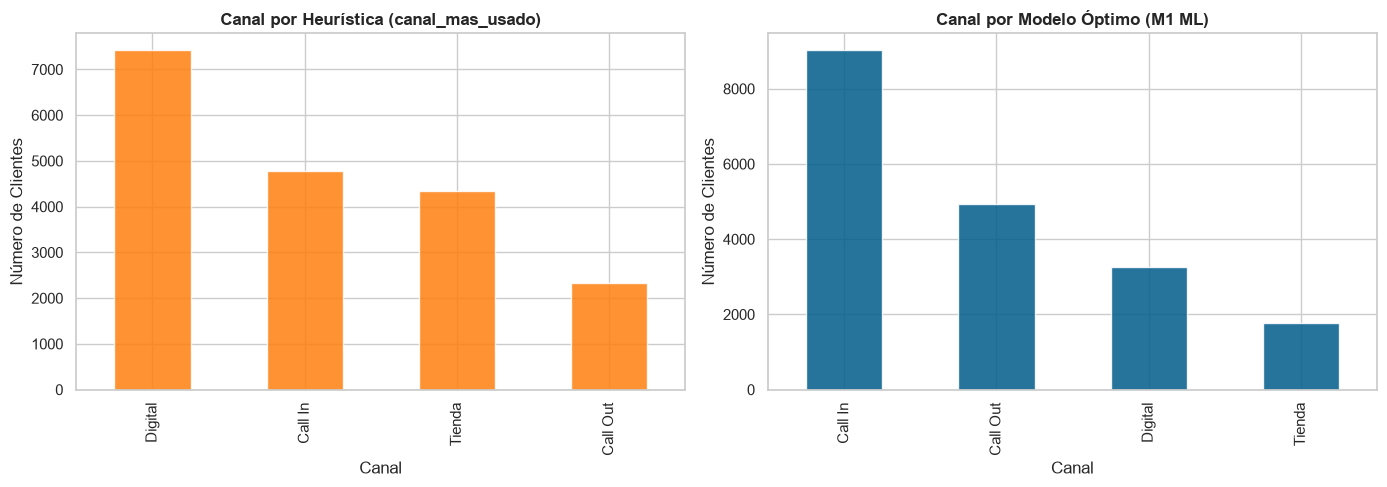

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Distribución Heurística vs ML
df_cli_test["canal_heuristica_b2"].value_counts().plot(
    kind="bar", ax=axes[0], color="#ff7f0e", alpha=0.85
)
axes[0].set_title("Canal por Heurística (canal_mas_usado)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Canal")
axes[0].set_ylabel("Número de Clientes")

df_cli_test["canal_optimo_ml"].value_counts().plot(
    kind="bar", ax=axes[1], color="#005c8a", alpha=0.85
)
axes[1].set_title("Canal por Modelo Óptimo (M1 ML)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Canal")
axes[1].set_ylabel("Número de Clientes")

plt.tight_layout()
plt.savefig(DIR_SALIDA / "distribucion_canales_recomendados.png", dpi=300)
plt.show()

## 10. Persistencia de Artefactos y Métricas

In [9]:
# Exportar tablas
df_metricas.to_csv(DIR_SALIDA / "metricas_modelos_contactabilidad.csv", index=False)
df_resumen_canales.to_csv(DIR_SALIDA / "comparativa_politicas_canal.csv", index=False)
imp_df.to_csv(DIR_SALIDA / "importancia_variables_contactabilidad.csv", index=False)

resumen_contact = {
    "universo_total_contactos": int(df_contact.shape[0]),
    "contactos_efectivos": int(df_contact["target_contacto"].sum()),
    "contactos_pendientes_no_contactados": int((df_contact["target_contacto"] == 0).sum()),
    "tasa_contactabilidad_base_pct": round(float(dist_contacto[1] * 100), 2),
    "metricas_modelos": df_metricas.to_dict(orient="records"),
    "benchmarks_politicas_canal": df_resumen_canales.to_dict(orient="records"),
    "lift_contacto_ml_vs_regla_pct": round(float(lift_contacto), 2)
}

with open(DIR_SALIDA / "resumen_ejecutivo_contactabilidad.json", "w", encoding="utf-8") as f:
    json.dump(resumen_contact, f, indent=2, ensure_ascii=False)

print(f"Artefactos exportados exitosamente en: {DIR_SALIDA.resolve()}")

Artefactos exportados exitosamente en: D:\hacka_movistar\data\processed\modelo_contactabilidad
